## Conhecendo os dados

In [1]:
url = 'https://raw.githubusercontent.com/alura-cursos/classificacao_xgboost/main/Dados/doenca_cardiaca.csv'

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(url)

In [4]:
df.head()

,Idade,Sexo,Tipo dor,Pressao arterial,Colesterol,Glicemia jejum >120,Resultados ECG,Frequencia cardiaca max,Dor exercicio,Depressao ST,Inclinacao ST,Numero vasos fluro,Teste cintilografia,Doenca cardiaca
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presenca
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Ausencia
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presenca
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Ausencia
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Ausencia


### EXplorando os dados

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Idade                    270 non-null    int64  
 1   Sexo                     270 non-null    int64  
 2   Tipo dor                 270 non-null    int64  
 3   Pressao arterial         270 non-null    int64  
 4   Colesterol               270 non-null    int64  
 5   Glicemia jejum >120      270 non-null    int64  
 6   Resultados ECG           270 non-null    int64  
 7   Frequencia cardiaca max  270 non-null    int64  
 8   Dor exercicio            270 non-null    int64  
 9   Depressao ST             270 non-null    float64
 10  Inclinacao ST            270 non-null    int64  
 11  Numero vasos fluro       270 non-null    int64  
 12  Teste cintilografia      270 non-null    int64  
 13  Doenca cardiaca          270 non-null    object 
dtypes: float64(1), int64(12), 

##### Dicionário das variáveis

* Idade: Idade em anos;
* Sexo: Sexo biológico (0 = feminino, 1 = masculino);
* Tipo dor: Tipo de dor no peito relatada pelo paciente (1= angina típica, 2 = angina atípica, 3 = não angina, 4 = angina assintomática).
* Pressao arterial: Pressão arterial medida em repouso.
* Colesterol: Nível de colesterol no sangue em miligramas por decilitro (mg/dl);
* Glicemia jejum >120: Nível de glicose no sangue em jejum, indicando se está abaixo de 120 mg/dl ou acima de 120 mg/dl (0 = abaixo, 1 = acima);
* Resultados ECG: Resultados do eletrocardiograma em repouso (0 = normal, 1 = anormalidade de onda ST-T, 2 = hipertrofia ventricular esquerda).
* Resultados ECG: Resultados do eletrocardiograma em repouso (0 = normal, 1 = anormalidade de onda ST-T, 2 = hipertrofia ventricular esquerda).
* Frequencia cardiaca max: Frequência cardíaca máxima alcançada durante um teste de esforço físico;
* Dor exercicio: Indica se houve angina (dor no peito) induzida por exercício ou não (0 = sim, 1 = não);
* Depressao ST: Medida da depressão do segmento ST induzida pelo exercício em relação ao repouso.
* Inclinacao ST: Inclinação do segmento ST no pico do exercício (1 = inclinado para cima, 2 = plano, 3 = inclinado para baixo).
* Numero vasos fluro: Número de vasos sanguíneos principais coloridos durante o procedimento de fluoroscopia.
* Teste cintilografia: Resultado do teste de estresse com tálio (3 = normal, 6 = defeito fixo, 7 = defeito reversível).

In [6]:
df.columns

Index(['Idade', 'Sexo', 'Tipo dor', 'Pressao arterial', 'Colesterol',
       'Glicemia jejum >120', 'Resultados ECG', 'Frequencia cardiaca max',
       'Dor exercicio', 'Depressao ST', 'Inclinacao ST', 'Numero vasos fluro',
       'Teste cintilografia', 'Doenca cardiaca'],
      dtype='object')

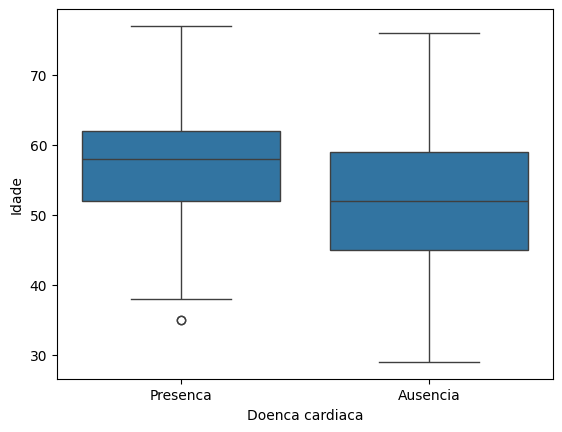

In [7]:
sns.boxplot(x='Doenca cardiaca', y ='Idade', data=df)
plt.show()

<Axes: xlabel='Sexo', ylabel='count'>

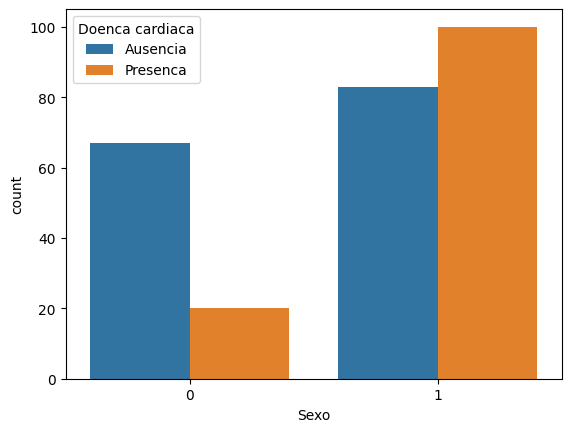

In [8]:
sns.countplot(x='Sexo', hue='Doenca cardiaca', data=df)

<Axes: xlabel='Tipo dor', ylabel='count'>

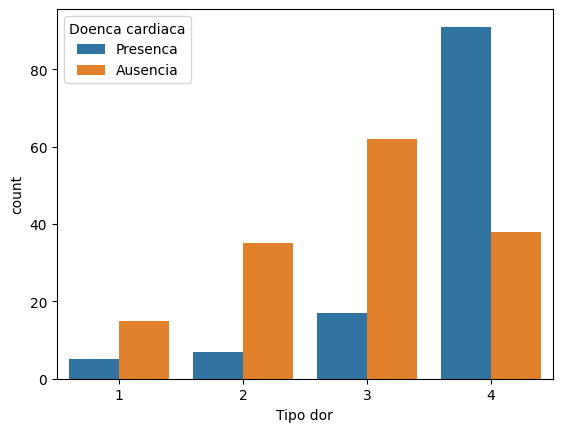

In [9]:
sns.countplot(x='Tipo dor', hue='Doenca cardiaca', data=df)

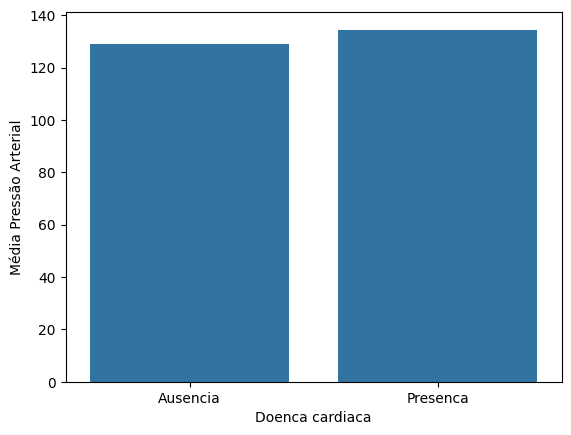

In [10]:
media_pressao_arterial_por_doenca = df.groupby('Doenca cardiaca')['Pressao arterial'].mean().reset_index()
media_pressao_arterial_por_doenca.rename(columns= {'Pressao arterial': 'Média Pressão Arterial'}, inplace=True)

sns.barplot(x='Doenca cardiaca', y='Média Pressão Arterial', data=media_pressao_arterial_por_doenca)
plt.show()

In [11]:
media_colesterol_por_doenca = df.groupby('Doenca cardiaca')['Colesterol'].mean().reset_index()
media_colesterol_por_doenca.rename(columns= {'Colesterol': 'Média Colesterol'}, inplace=True)
media_colesterol_por_doenca

,Doenca cardiaca,Média Colesterol
0,Ausencia,244.213333
1,Presenca,256.466667


<Axes: xlabel='Glicemia jejum >120', ylabel='count'>

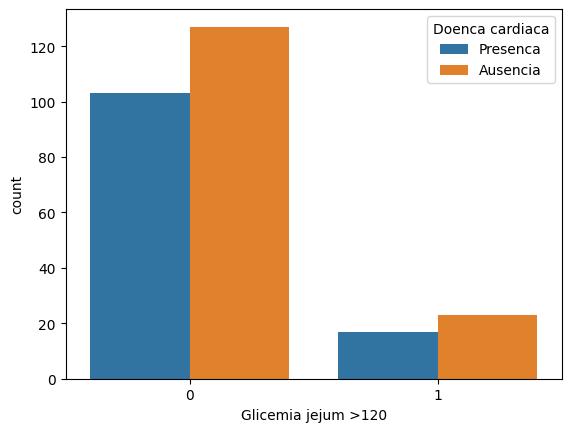

In [12]:
sns.countplot(x='Glicemia jejum >120', hue='Doenca cardiaca', data=df)

In [13]:
df.columns

Index(['Idade', 'Sexo', 'Tipo dor', 'Pressao arterial', 'Colesterol',
       'Glicemia jejum >120', 'Resultados ECG', 'Frequencia cardiaca max',
       'Dor exercicio', 'Depressao ST', 'Inclinacao ST', 'Numero vasos fluro',
       'Teste cintilografia', 'Doenca cardiaca'],
      dtype='object')

<Axes: xlabel='Resultados ECG', ylabel='count'>

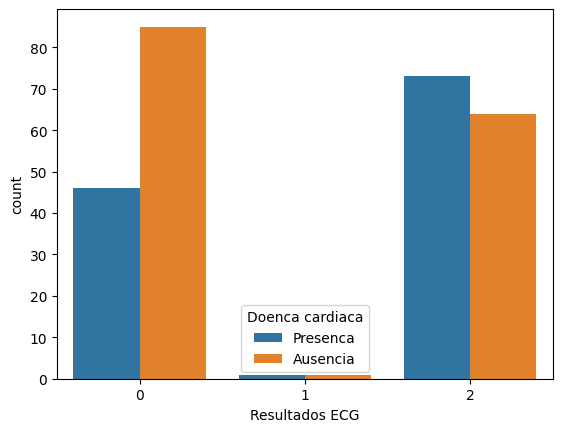

In [14]:
sns.countplot(x='Resultados ECG', hue='Doenca cardiaca', data=df)

In [15]:
media_frequencia_cardiaca_por_doenca = df.groupby('Doenca cardiaca')['Frequencia cardiaca max'].mean()
media_frequencia_cardiaca_por_doenca

,Frequencia cardiaca max
Doenca cardiaca,
Ausencia,158.333333
Presenca,138.858333


* Em corações saudáveis, o sistema elétrico responde prontamente ao esforço, elevando os batimentos para oxigenar os músculos.

* Em muitos pacientes com doenças cardíacas, o "marcapasso natural" do coração (o nó sinoatrial) ou as vias de condução podem estar danificados, impedindo que a frequência suba tanto quanto a de uma pessoa saudável.

<Axes: xlabel='Dor exercicio', ylabel='count'>

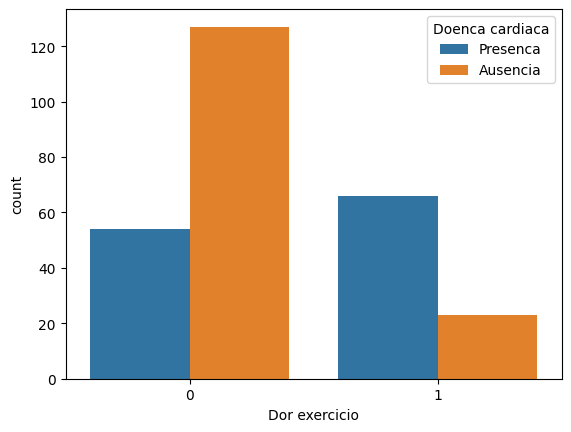

In [16]:
sns.countplot(x='Dor exercicio', hue='Doenca cardiaca', data=df)

<Axes: xlabel='Numero vasos fluro', ylabel='count'>

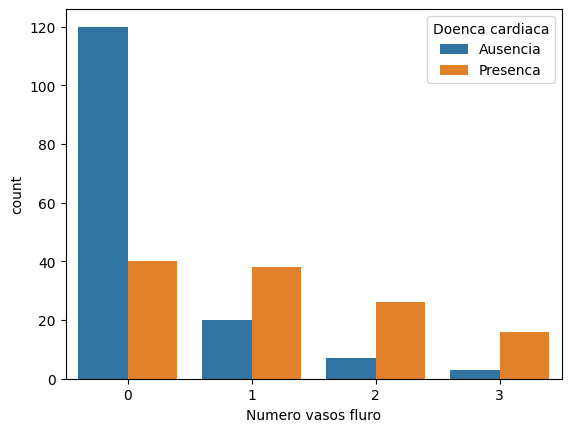

In [17]:
sns.countplot(x='Numero vasos fluro', hue='Doenca cardiaca', data=df)

In [18]:
#analisando a forma que a variável target esta balanceada
df['Doenca cardiaca'].value_counts()

,count
Doenca cardiaca,
Ausencia,150
Presenca,120


In [19]:
df['Doenca cardiaca'] = df['Doenca cardiaca'].map({'Ausencia': 0, 'Presenca': 1})

In [20]:
df

,Idade,Sexo,Tipo dor,Pressao arterial,Colesterol,Glicemia jejum >120,Resultados ECG,Frequencia cardiaca max,Dor exercicio,Depressao ST,Inclinacao ST,Numero vasos fluro,Teste cintilografia,Doenca cardiaca
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,0
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,0
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,0
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,0


## Iniciando a classificação

### Separando os dados

In [21]:
X = df.drop('Doenca cardiaca', axis=1)
y = df['Doenca cardiaca']

# outra forma X, y = df.iloc[:,:-1], df.iloc[:,-1]

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### Classificando com Decision Tree

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

dt = DecisionTreeClassifier(random_state=0)

dt.fit(X_treino, y_treino)

y_pred = dt.predict(X_teste)

print(classification_report(y_teste, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.73      0.77        30
           1       0.70      0.79      0.75        24

    accuracy                           0.76        54
   macro avg       0.76      0.76      0.76        54
weighted avg       0.77      0.76      0.76        54



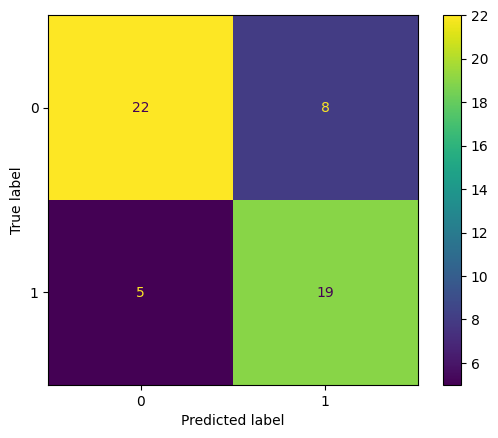

In [25]:
matriz_confusao = confusion_matrix(y_teste,y_pred)

visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=dt.classes_)
visualizacao.plot();

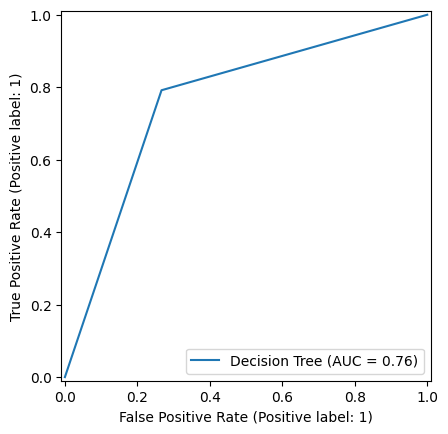

In [26]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(dt, X_teste, y_teste, name='Decision Tree')

### Classificando com XGBoost

In [27]:
import xgboost as xgb

In [28]:
xg_cl = xgb.XGBClassifier(objective='binary:logistic')

xg_cl.fit(X_treino, y_treino)

y_pred = xg_cl.predict(X_teste)

print(classification_report(y_teste, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83        30
           1       0.77      0.83      0.80        24

    accuracy                           0.81        54
   macro avg       0.81      0.82      0.81        54
weighted avg       0.82      0.81      0.82        54



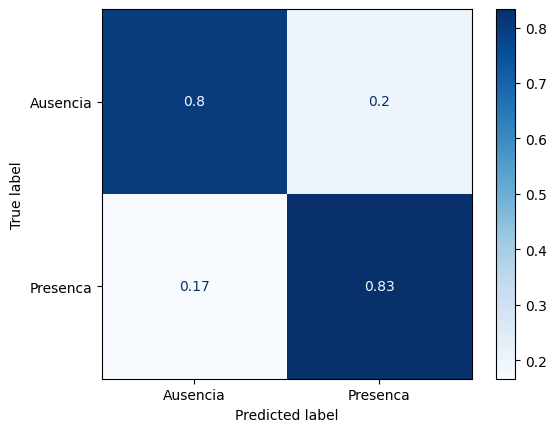

In [29]:
ConfusionMatrixDisplay.from_estimator(xg_cl, X_teste, y_teste, display_labels=['Ausencia', 'Presenca'],
                                                                    normalize='true', cmap='Blues');

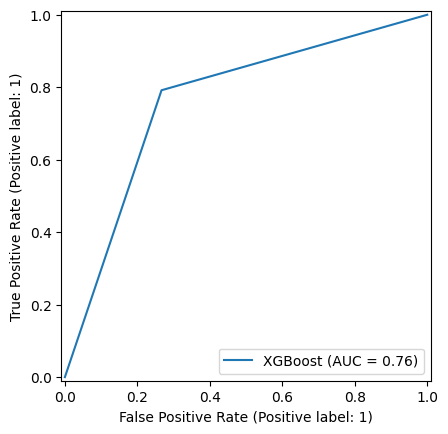

In [30]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(dt, X_teste, y_teste, name='XGBoost')

## Realizando validação cruzada

### Aplicando a validação cruzada

In [31]:
dmatrix = xgb.DMatrix(data=X, label=y)

In [32]:
params = {'objective': 'binary:logistic'}

params = {'objective': 'binary:logistic'}

cv_resultados = xgb.cv(dtrain=dmatrix, params=params, nfold=3, num_boost_round=5, metrics='error',
                                       as_pandas=True, seed=123)
print(cv_resultados)
acuracia = 1 - cv_resultados['test-error-mean'].iloc[-1]
print(f'Acurácia: {acuracia}')

   train-error-mean  train-error-std  test-error-mean  test-error-std
0          0.138889         0.023570         0.288889        0.055184
1          0.081481         0.010476         0.262963        0.010476
2          0.068519         0.013858         0.248148        0.037771
3          0.050000         0.007857         0.229630        0.010476
4          0.046296         0.010476         0.225926        0.022831
Acurácia: 0.774074074074074


### Explorando a técnica de Early Stopping

In [33]:
params = {'objective': 'binary:logistic'}

cv_resultados = xgb.cv(dtrain=dmatrix, params=params, nfold=3, num_boost_round=100, early_stopping_rounds=5, metrics='error',
                       as_pandas=True, seed=123)

print(cv_resultados)
acuracia = 1 - cv_resultados['test-error-mean'].iloc[-1]
print(f"Acurácia: {acuracia}")

   train-error-mean  train-error-std  test-error-mean  test-error-std
0          0.138889         0.023570         0.288889        0.055184
1          0.081481         0.010476         0.262963        0.010476
2          0.068519         0.013858         0.248148        0.037771
3          0.050000         0.007857         0.229630        0.010476
4          0.046296         0.010476         0.225926        0.022831
5          0.033333         0.013608         0.214815        0.013858
6          0.024074         0.006929         0.207407        0.013858
Acurácia: 0.7925925925925926


## Ajustando hiperparâmetros do XGBoost

### Conhecendo os principais hiperparâmetros

In [34]:
params = {'objective':'binary:logistic', 'colsample_bytree': 0.3,
          'learning_rate': 0.1, 'max_depth': 5}

cv_resultados = xgb.cv(dtrain=dmatrix, params=params,
                  nfold=3, num_boost_round=100, early_stopping_rounds=5,
                  metrics='error', as_pandas=True, seed=123)

print(cv_resultados)
acuracia = 1 - cv_resultados['test-error-mean'].iloc[-1]
print(f'Acuracia: {acuracia}')

    train-error-mean  train-error-std  test-error-mean  test-error-std
0           0.307407         0.061586         0.359259        0.135881
1           0.262963         0.093661         0.344444        0.148518
2           0.224074         0.057794         0.292593        0.109369
3           0.177778         0.065420         0.318519        0.082319
4           0.166667         0.040318         0.259259        0.063721
5           0.153704         0.032815         0.259259        0.049966
6           0.135185         0.026579         0.248148        0.044752
7           0.129630         0.018332         0.244444        0.031427
8           0.107407         0.013858         0.233333        0.024003
9           0.105556         0.012001         0.229630        0.020951
10          0.101852         0.013095         0.229630        0.005238
11          0.096296         0.009443         0.218519        0.020951
12          0.092593         0.011416         0.211111        0.015713
13    

* **learning_rate (Taxa de Aprendizado):**

Desempenha um papel crucial no ajuste do modelo ao erro residual com modelos base adicionais.
O valor padrão é 0.3, mas pode ser ajustado entre 0 e 1.
Taxas de aprendizado mais baixas requerem mais iterações para alcançar a mesma redução de erro, enquanto taxas mais altas podem acelerar o processo.

* **max_depth (Profundidade Máxima da Árvore):**

Afeta a profundidade máxima que cada árvore pode atingir em cada rodada de impulso.
O valor padrão é 6, mas pode ser definido como qualquer inteiro positivo.
Aumentar a profundidade pode levar a um modelo mais complexo e potencialmente a problemas de sobreajuste.

* **colsample_bytree (Fração de Features por Árvore):**

Determina a fração de features utilizada em cada rodada de impulso.
O valor padrão é 1, indicando o uso de todas as features; pode ser ajustado entre 0 e 1.
Valores menores fornecem regularização adicional, enquanto valores maiores podem levar a sobreajuste.

* **gamma (Redução Mínima de Perdas):**

Define a redução mínima de perdas necessária para realizar uma partição adicional em um nó da árvore.
O padrão é 0, mas pode ser definido como qualquer inteiro positivo.
Um valor mais alto torna o algoritmo mais conservador, resultando em menos divisões na árvore.

* **subsample (Fração de Conjunto de Treinamento):**

Indica a fração do conjunto de treinamento utilizada em cada rodada de impulso.
O padrão é 1, podendo ser ajustado entre 0 e 1.
Valores baixos podem resultar em subajuste, enquanto valores altos podem levar a sobreajuste.

* **lambda (Termo de Regularização L2):**

O parâmetro lambda é usado para controlar a penalização L2 (regularização Ridge) nas folhas da árvore.
O valor padrão é 1, podendo ser ajustado para qualquer inteiro positivo.
Ele adiciona uma penalidade à complexidade do modelo, ajudando a evitar o overfitting.
Aumentar este valor torna o modelo mais conservador.

* **alpha (Termo de Regularização L1):**

O parâmetro alpha controla a penalização L1 (regularização Lasso) nas folhas da árvore.
O padrão é 0, mas pode ser alterado para qualquer inteiro positivo.
Assim como o parâmetro lambda, o alpha ajuda a controlar a complexidade do modelo e prevenir overfitting.
Aumentar este valor aumenta a regularização e torna o modelo mais conservador.

### Aplicando o Random Search

In [35]:
from sklearn.model_selection import RandomizedSearchCV

In [36]:
params = {
        'learning_rate': [0.1, 0.2, 0.3],
        'max_depth': [0, 2, 4, 6, 10],
        'colsample_bytree': [0.1, 0.5, 1],
        'n_estimators': [10, 25, 50],
}

In [37]:
modelo_xgb = xgb.XGBClassifier()

random_search_cv = RandomizedSearchCV(estimator=modelo_xgb, param_distributions=params, n_iter=5, cv=4, scoring='accuracy', verbose=1)

In [38]:
random_search_cv.fit(X, y)

Fitting 4 folds for each of 5 candidates, totalling 20 fits


RandomizedSearchCV(cv=4,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=5,
                   param_distributions={'colsample_bytree': [0.1, 0.5, 1],
                                        'learning_rate': [0.1, 0.2, 0.3],
                                        'max_depth': [0, 2, 4, 6, 10],
                                        'n_estimators': [10, 25, 50]},
                   scoring='accuracy', verbose=1)

In [39]:
print('Melhores parametros encontrados: ', random_search_cv.best_params_)
print("Acuracia:", random_search_cv.best_score_)

Melhores parametros encontrados:  {'n_estimators': 10, 'max_depth': 2, 'learning_rate': 0.1, 'colsample_bytree': 0.5}
Acuracia: 0.8294556628621599


### Aplicando o Grid Search

In [40]:
from sklearn.model_selection import GridSearchCV

In [41]:
grid_search_cv = GridSearchCV(estimator=modelo_xgb, param_grid=params, cv=4, scoring='accuracy', verbose=1)

grid_search_cv.fit(X, y)

Fitting 4 folds for each of 135 candidates, totalling 540 fits


GridSearchCV(cv=4,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'colsample_bytree': [0.1, 0.5, 1],
                         'learning_rate': [0.1, 0.2, 0.3],
                         'max_depth': [0, 2, 4, 6, 10],
                         'n_estimators': [10, 25, 50]},
             scoring='accuracy', verbose=1)

In [42]:
print('Melhores parametros encontrados: ', grid_search_cv.best_params_)
print('Acuracia: ', grid_search_cv.best_score_)

Melhores parametros encontrados:  {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 50}
Acuracia:  0.8409240561896401


### Analisando as métricas após ajuste dos hiperparâmetros

In [43]:
xg_cl_ajustado = xgb.XGBClassifier(objective='binary:logistic', colsample_bytree=1, learning_rate=0.1, max_depth=2, n_estimators=50)

xg_cl_ajustado.fit(X_treino, y_treino)

y_pred = xg_cl_ajustado.predict(X_teste)

In [44]:
report = classification_report(y_teste, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.89      0.83      0.86        30
           1       0.81      0.88      0.84        24

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.86      0.85      0.85        54



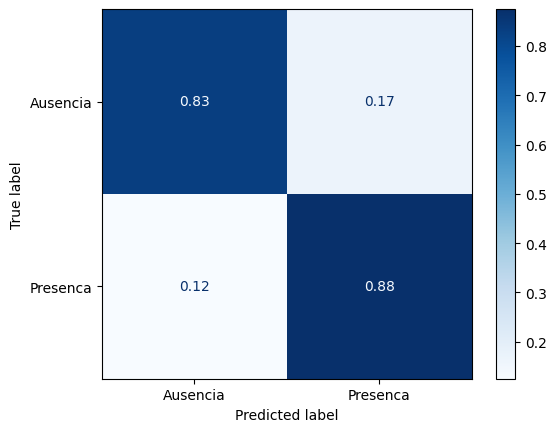

In [45]:
ConfusionMatrixDisplay.from_estimator(xg_cl_ajustado, X_teste, y_teste, display_labels=['Ausencia', 'Presenca'],
                                                                    normalize='true', cmap='Blues');

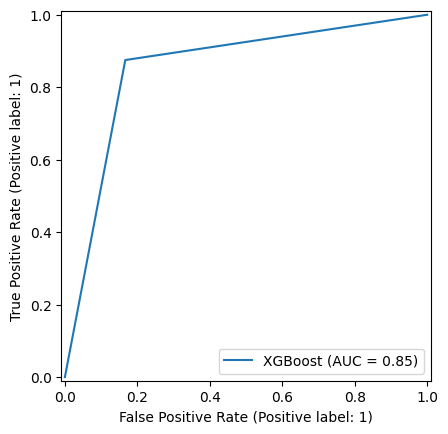

In [46]:
RocCurveDisplay.from_predictions(y_teste, y_pred, name='XGBoost')

## Utilizando o XGBoost em pipelines

### Incorporando XGBoost em pipelines

In [49]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('xgboost', xgb.XGBClassifier())
])

xgb_params = {
    'xgboost__learning_rate': [0.1, 0.2, 0.3],
    'xgboost__max_depth': [0, 2, 4, 6, 10],
    'xgboost__colsample_bytree': [0.1, 0.5, 1],
    'xgboost__n_estimators': [10, 25, 50]
    }

grid_search_cv = GridSearchCV(estimator=pipeline, param_grid=xgb_params, cv=4, scoring='accuracy', verbose=1)

grid_search_cv.fit(X, y)

print('Acuracia:', grid_search_cv.best_score_)
print('Melhor estimador:', grid_search_cv.best_estimator_)

Fitting 4 folds for each of 135 candidates, totalling 540 fits
Acuracia: 0.8409240561896401
Melhor estimador: Pipeline(steps=[('xgboost',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=1, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=2, max_leaves=None,
                               min_

In [50]:
import joblib

joblib.dump(grid_search_cv, 'modelo_pipeline.pkl')

['modelo_pipeline.pkl']

### Utilizando o modelo com dados novos

In [51]:
modelo = joblib.load('modelo_pipeline.pkl')

In [54]:
url = 'https://raw.githubusercontent.com/alura-cursos/classificacao_xgboost/main/Dados/pacientes_novos.csv'

novos_pacientes = pd.read_csv(url)
novos_pacientes

,Idade,Sexo,Tipo dor,Pressao arterial,Colesterol,Glicemia jejum >120,Resultados ECG,Frequencia cardiaca max,Dor exercicio,Depressao ST,Inclinacao ST,Numero vasos fluro,Teste cintilografia
0,41,1,4,110,172,0,2,158,0,0.0,1,0,7
1,45,0,4,102,265,0,2,122,0,0.6,2,0,3
2,50,1,3,130,246,1,2,173,0,0.0,1,3,3
3,52,0,4,100,248,0,2,122,0,1.0,2,0,3
4,54,0,3,110,214,0,0,158,0,1.6,2,0,3
5,70,0,1,140,239,0,0,151,0,1.8,1,2,3
6,42,0,4,132,341,1,2,136,1,3.0,2,0,7
7,34,0,1,150,283,1,2,162,0,1.0,1,0,3
8,52,1,1,118,186,0,2,190,0,0.0,2,0,6
9,35,1,4,112,245,0,0,150,0,1.0,2,2,3


In [55]:
previsoes = modelo.predict(novos_pacientes)

In [56]:
previsoes

array([1, 0, 0, 0, 0, 0, 1, 0, 0, 1])

In [57]:
probabilidades = modelo.predict_proba(novos_pacientes)

In [58]:
probabilidades

array([[0.47393423, 0.52606577],
       [0.8558979 , 0.14410211],
       [0.7332415 , 0.2667585 ],
       [0.78785014, 0.21214986],
       [0.9572766 , 0.04272339],
       [0.8929918 , 0.10700822],
       [0.09207231, 0.9079277 ],
       [0.885187  , 0.11481301],
       [0.9037268 , 0.09627319],
       [0.20895249, 0.7910475 ]], dtype=float32)

In [59]:
df_novos_pacientes = pd.DataFrame(novos_pacientes)

df_novos_pacientes['previsoes'] = previsoes

df_novos_pacientes

,Idade,Sexo,Tipo dor,Pressao arterial,Colesterol,Glicemia jejum >120,Resultados ECG,Frequencia cardiaca max,Dor exercicio,Depressao ST,Inclinacao ST,Numero vasos fluro,Teste cintilografia,previsoes
0,41,1,4,110,172,0,2,158,0,0.0,1,0,7,1
1,45,0,4,102,265,0,2,122,0,0.6,2,0,3,0
2,50,1,3,130,246,1,2,173,0,0.0,1,3,3,0
3,52,0,4,100,248,0,2,122,0,1.0,2,0,3,0
4,54,0,3,110,214,0,0,158,0,1.6,2,0,3,0
5,70,0,1,140,239,0,0,151,0,1.8,1,2,3,0
6,42,0,4,132,341,1,2,136,1,3.0,2,0,7,1
7,34,0,1,150,283,1,2,162,0,1.0,1,0,3,0
8,52,1,1,118,186,0,2,190,0,0.0,2,0,6,0
9,35,1,4,112,245,0,0,150,0,1.0,2,2,3,1
